# Regularization of linear regression with norms and constraints

## Steps

1. Repeat gradient descent with two (and more) variables
2. Regularization with the $L^2$ Norm
3. Parameter Tying with the $L^2$ Norm
4. Regularization with the $L^1$ Norm
5. Regularization with the $L^2$ Norm constraint
6. Regularization with the $L^1$ Norm constraint
7. Regularization of underconstraint problems

In [42]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Redefine all relevant functions from past notebook

Numerical Linear Regression.ipynb

In [43]:
def rss2(a, b, X, Y):
    n = len(X)
    err = 0
    for i in range(n):
        err += (Y[i] - a*X[i] - b)**2
    return err

def grad_rss2(a, b, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2
    grad_b = grad_b * -2
    grad_w = [grad_a, grad_b]
    return grad_w

def grad_desc_rss2(K, a0, b0, X, Y, learning_eps, f, ff, verbose):
    a = np.zeros((K+1,1))
    b = np.zeros((K+1,1))
    a[0] = a0
    b[0] = b0

    if verbose:
        plt.figure()
        plt.plot(a0, b0, "ro")

    for k in range(K):
        [grad_a, grad_b] = ff(a[k], b[k], X, Y)
        a[k+1] = a[k] - learning_eps * grad_a
        b[k+1] = b[k] - learning_eps * grad_b

        if verbose:
            plt.plot([a[k], a[k+1]], [b[k], b[k+1]], "r-")
            plt.plot(a[k+1], b[k+1], "ro", markersize=3)

    if verbose:
        alow = np.min(a)
        alow = np.min([alow, a0-2])
        ahigh = np.max(a)
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(b)
        blow = np.min([blow, b0-6])
        bhigh = np.max(b)
        bhigh = np.max([bhigh, b0+6])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, f(A, B, X, Y), cmap="viridis")
        plt.show()
    
    return [a, b]

## Repeat gradient descent with two (and more) variables

Check the Notebook: "Numerical Linear Regression".

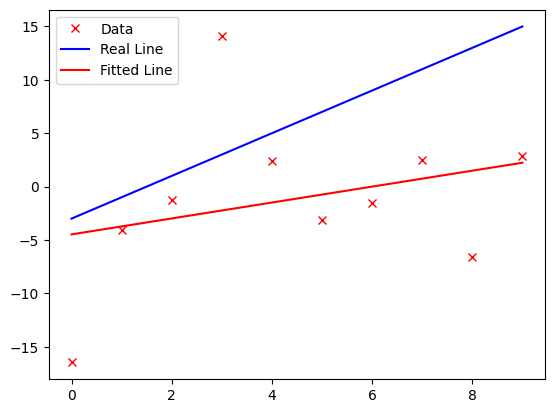

In [44]:
# np.random.seed(1)

a0 = 2
b0 = -3

N = 10

X = np.arange(0, 10, 1)
Y = a0 * X + b0 + np.random.normal(0, 10, 10)

A, B = grad_desc_rss2(1000, a0, b0, X, Y, 0.001, rss2, grad_rss2, False)

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, A[-1] * X + B[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

We learn $\hat a$ and $\hat b$ from the data and expect them to be $\approx 2$ and $\approx -3$, respectively. 
Therefore, we minimize the residual sum of squares; $(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2$.  

Let's 3D plot the $RSS$ as a function of $a$ and $b$. We chose the ranges of $a$ and $b$ around the (actually unknown) minima of $\approx 2$ and $\approx -3$, respectively. 

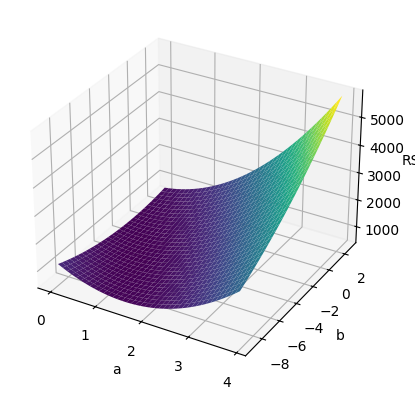

In [45]:
[A, B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))


fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot_surface(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("RSS")
plt.show()

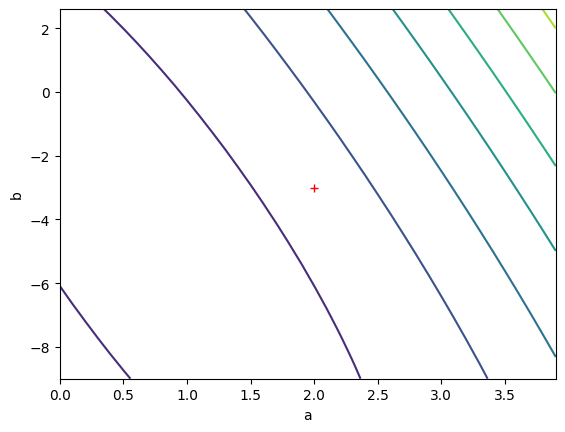

In [46]:
fig = plt.figure()
ax = plt.axes()
ax.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.plot(a0, b0, "r+")
ax.set_xlabel("a")
ax.set_ylabel("b")
plt.show()

The gradient of $RSS(a,b)$ for any $a, b$ is defiend as:

$$
\begin{aligned}
\nabla RSS(a,b) &= \left [ \frac{\partial RSS(a,b)}{\partial a}, \frac{\partial RSS(a,b)}{\partial b}\right ]^T\\
&= -2 \left [ \sum_{i=1}^{n}(y_i- a x_i-b)x_i, \sum_{i=1}^{n}(y_i- a x_i-b) \right ]^T 
\end{aligned}
$$

The gradient descent find the minimum.

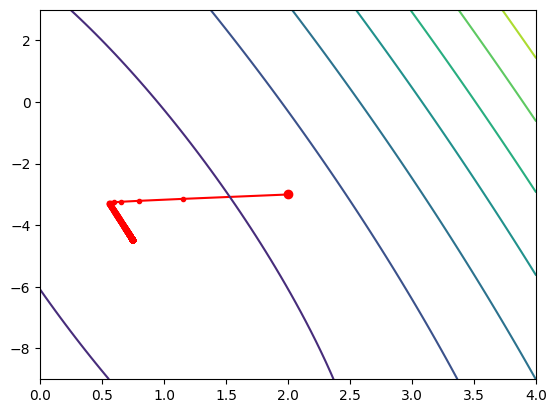

In [47]:
K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255

[a, b] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, rss2, grad_rss2, verbose=True)

Here the final result.

Orig: a=0.75 b=-4.48 loss=[507.06409379]


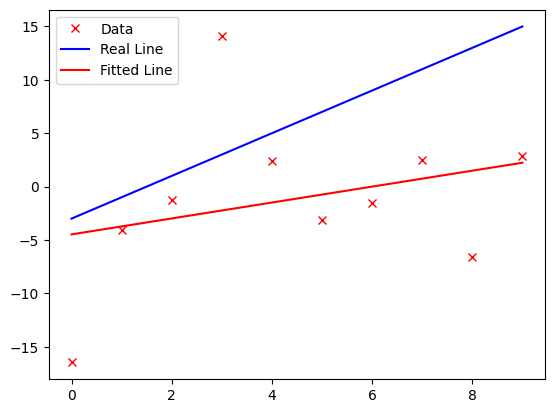

In [48]:
a_orig = a[0]
b_orig = b[0]

print(f"Orig: a={a[-1][0]:.2f} b={b[-1][0]:.2f} loss={rss2(a[-1], b[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, a[-1] * X + b[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## Regularization with the $L^2$ Norm

We add a penalty term to the loss function proportional to the square of the $L^2$ Norm of the parameters: $a^2 + b^2$. 

The regulated loss function is 
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^2}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2)$$
for some parameter $\alpha$.

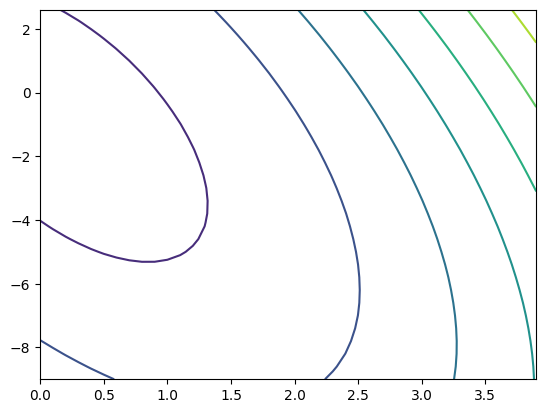

In [49]:
# alpha =0.1
# alpha =1
alpha =10

def L2(a, b, X, Y):
    return rss2(a, b, X, Y) + alpha*(a**2 + b**2)

[A,B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))

fig, ax = plt.subplots()
ax.contour(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4), L2(A, B, X, Y))
plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2}(a,b) 
&= \left [ \frac{\partial RSS_{L^2}(a,b)}{\partial a}, \frac{\partial RSS_{L^2}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha a, \frac{\partial RSS(a,b)}{\partial b}+2\alpha b\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha a, -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha b\right ]^T 
\end{aligned}
$$

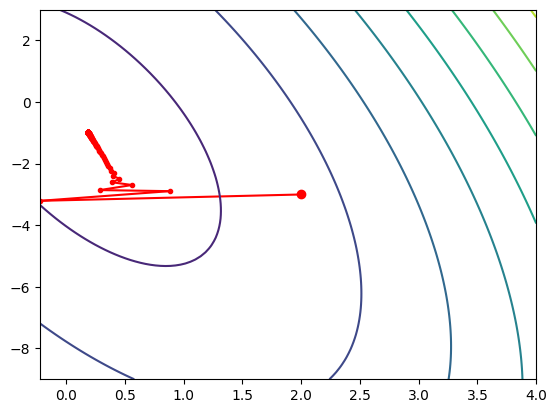

In [50]:
def grad_L2(a, b, X, Y):
    return grad_rss2(a, b, X, Y) + 2*alpha*np.array([a, b])

K = 1000
# learning_eps = 0.001
# learning_eps = 0.0001
learning_eps = 0.0025
# learning_eps = 0.00255

[aL2, bL2] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, L2, grad_L2, verbose=True)

L2: a=0.19 b=-0.98 loss=[552.5185085]


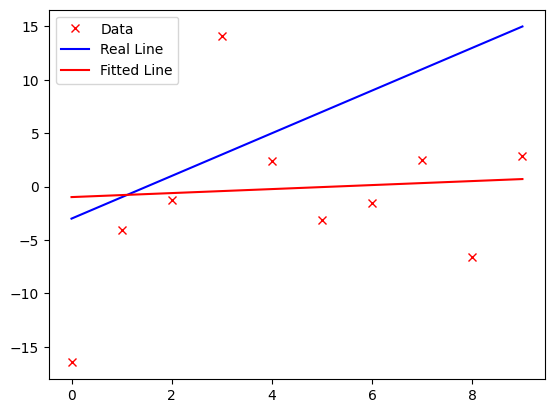

In [51]:
print(f"L2: a={aL2[-1][0]:.2f} b={bL2[-1][0]:.2f} loss={L2(aL2[-1], bL2[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, aL2[-1] * X + bL2[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

As expected, we observe that the length of the parameter vector gets smaller while the loss became larger: $a=2.09\ (2.49), b=-5.66\ (-8.44)$ while the loss became larger: $RSS=460.67\ (444.1)$.

## Parameter Tying 

For demonstrating the approach, let's tie the parameters to the (usually unknown) gorund truth: $a_0 = 2,
b_0 = -3$. We add a penalty term to the loss function proportional to the square of the $L^2$ Norm of the parameters **difference** vector: $(a-a_0)^2 + (b-b_0)^2$. 

The regulated loss function is 
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^2, a_0, b_0}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha((a-a_0)^2 + (b-b_0)^2)$$
for some parameter $\alpha$.

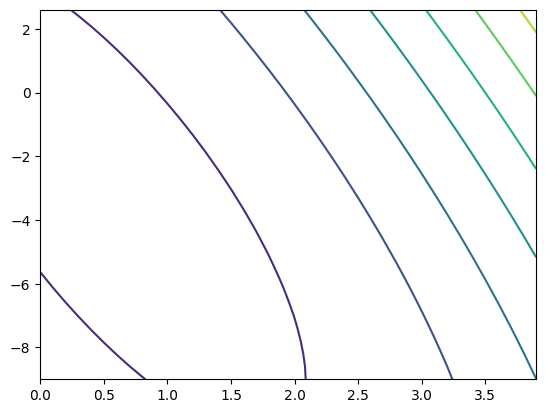

In [52]:
alpha =1

def L2t(a, b, X, Y):
    return L2(a, b, X, Y) + alpha*((a-a0)**2 + (b-b0)**2)

[A, B] = np.meshgrid(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4))

fig, ax = plt.subplots()
ax.contour(np.arange(a0-2, a0+2, 0.1,), np.arange(b0-6, b0+6, 0.4), L2t(A, B, X, Y))
plt.show()

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^2, a_0, b_0}(a,b) 
&= \left [ \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial a}, \frac{\partial RSS_{L^2, a_0, b_0}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +2\alpha (a-a_0), \frac{\partial RSS(a,b)}{\partial b}+2\alpha (b - b_0)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2 \alpha (a-a_0), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +2 \alpha (b - b_0)\right ]^T 
\end{aligned}
$$

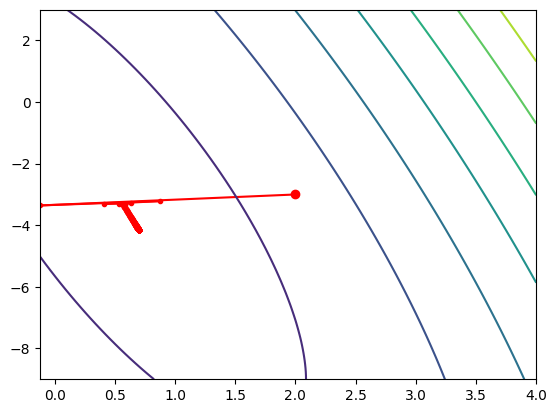

In [53]:
def grad_L2t(a, b, X, Y):
    return grad_rss2(a, b, X, Y) + 2*alpha*np.array([a-a0, b-b0])

K = 1000
# learning_eps = 0.001
# learning_eps = 0.0001
learning_eps = 0.0025
# learning_eps = 0.00255

[aL2t, bL2t] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, L2t, grad_L2t, verbose=True)

L2 tying: a=0.70 b=-4.15 loss=[525.1233634]


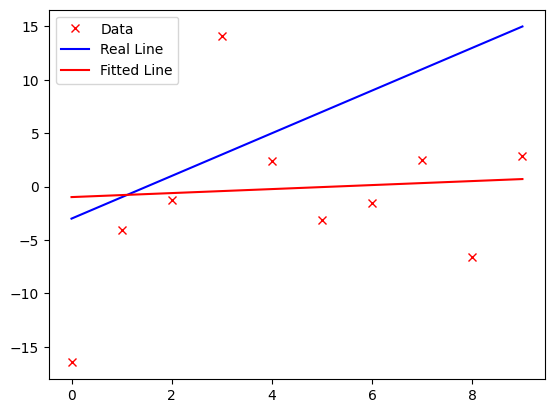

In [54]:
print(f"L2 tying: a={aL2t[-1][0]:.2f} b={bL2t[-1][0]:.2f} loss={L2(aL2t[-1], bL2t[-1], X, Y)}")

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Data")
ax.plot(X, a0 * X + b0, "b-", label="Real Line")
ax.plot(X, aL2[-1] * X + bL2[-1], "r-", label="Fitted Line")
plt.legend()
plt.show()

## Regularization with the $L^1$ Norm

We add a penalty term to the loss function proportional to the $L^1$ Norm, i.e., sum of the absolute values of the parameters: $|a| + |b|$. 

The regulated loss function is now:
$$(\hat a, \hat b) = \arg \min_{a,b} RSS_{L^1}(a,b)=\sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(|a| + |b|)$$
for some parameter $\alpha$.

In [55]:
alpha = 100;
fL1 = @(a,b)(f(a,b)+alpha*(abs(a) + abs(b)));
[A,B] = meshgrid(a0-2:0.01:a0+2,b0-6:0.04:b0+6);
plot3d(fL1, A, B, false) %contour

SyntaxError: invalid syntax (2405037116.py, line 2)

The the new gradient of is:

$$
\begin{aligned}
\nabla RSS_{L^1}(a,b) 
&= \left [ \frac{\partial RSS_{L^1}(a,b)}{\partial a}, \frac{\partial RSS_{L^1}(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +\alpha\ \text{sign}(a), \frac{\partial RSS(a,b)}{\partial b}+\alpha\ \text{sign}(b)\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\   \text{sign}(b)\right ]^T 
\end{aligned}
$$

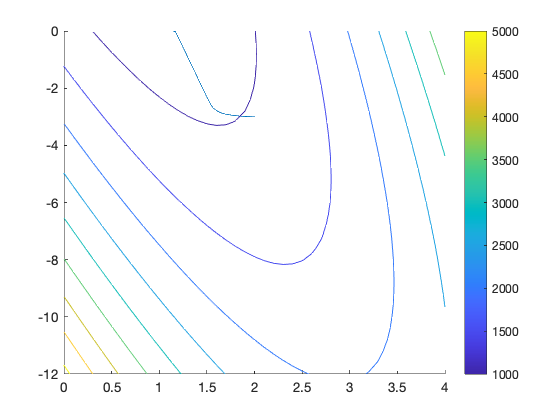

In [ ]:
ffL1 = @(a,b)(ff(a,b)+[alpha*sign(a);alpha*sign(b)]);
K = 5000;
%learning_eps = 0.001;
learning_eps = 0.0001;
%learning_eps = 0.0025;
[as, bs] = grad_desc_rss2(K, a0, b0, learning_eps, fL1, ffL1, true);
[as, bs].';

L1 a=1.15 b=-0.00 loss=603.13


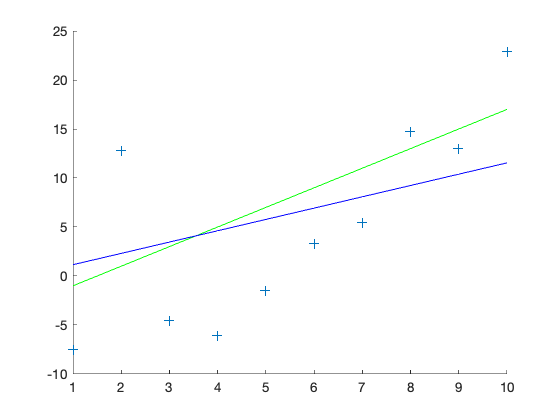

In [ ]:
fprintf("L1 a=%.2f b=%.2f loss=%.2f",as(K+1),bs(K+1),rss2(as(K+1),bs(K+1),X,Y));
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,as(K+1)*X+bs(K+1),'color','b')
hold off

As expected, we observe that the loss became larger. Using a high value of $\alpha$, we enforced an inappropriately high penalty. This way, we could observe increased sparsity, i.e., that the parameter $b$ has an optimal value of (close to) zero.

## 4. Regularization with the $L^2$ Norm constraint

### 4.1 The $L^2$ Norm equality constraint

A similar approach adds an equality constraint to the square of the $L^2$ Norm of the parameters: $a^2 + b^2$. 

This is actually not a real regularization that makes sense. However, the modifired loss function would be 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } a^2 + b^2& = c
\end{aligned}
$$  
for some a constant $c$.

The equality constraint $(a^2 + b^2) = c$ is equal to the equality constraint $a^2 + b^2 - c = 0$. For the loss function with the equality constraint, we define the Lagrangian:

$$
\begin{aligned}
\mathcal{L}^2(a,b,\alpha) &= RSS(a,b) + \alpha(a^2 + b^2 -c)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2 -c)
\end{aligned}
$$

The the gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^2(a,b,\alpha) 
&= \left [ \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial a}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial b}, \frac{\partial \mathcal{L}^2(a,b,\alpha)}{\partial \alpha} \right ]^T\\
&= \left [ 
\frac{\partial RSS(a,b)}{\partial a} + 2\alpha a, 
\frac{\partial RSS(a,b)}{\partial b} + 2\alpha b, 
a^2 + b^2 -c\right ]^T\\
&= \left [
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a, 
-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b, 
a^2 + b^2 -c\right ]^T 
\end{aligned}
$$

In [ ]:
%%file grad_rss3e.m
function grad_w = grad_rss3e(a, b, alpha, c, X, Y)
    n = length(X);
    grad_a = 0;
    grad_b = 0;
    for i=1:n
        tmp = Y(i) - a*X(i) - b;
        grad_a = grad_a + tmp *X(i);
        grad_b = grad_b + tmp;
    end
    grad_a = -2*grad_a + 2*alpha*a;
    grad_b = -2*grad_b + 2*alpha*b;
    grad_alpha = a^2 + b^2 -c;
    grad_w = [grad_a; grad_b; grad_alpha];
end

Created file '/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/grad_rss3e.m'.


In [ ]:
%%file grad_desc_rss3e.m
function [as, bs, alphas] = grad_desc_rss3e(K, a0, b0, alpha0, learning_eps, f_orig, f, ff, verbose)
    as = zeros(K+1,1);
    bs = zeros(K+1,1);
    alphas = zeros(K+1,1);
    as = zeros(K+1,1);
    as(1)=a0;
    bs(1)=b0;
    alphas(1)=alpha0;
    for k = 1:K
        grad_w = ff(as(k),bs(k),alphas(k));
        grad_a = grad_w(1);
        grad_b = grad_w(2);
        grad_alpha = grad_w(3);
        as(k+1)= as(k) - learning_eps * grad_a;
        bs(k+1)= bs(k) - learning_eps * grad_b;
        alphas(k+1)= alphas(k) - learning_eps * grad_alpha;
        if verbose
            line([as(k),as(k+1)],[bs(k),bs(k+1)])
            hold on
        end
    end
    grad_w = ff(as(k),bs(k),alphas(k))
    ffinal = @(a,b)(f(a, b, alphas(K+1)));
    if verbose
        alow = min([as.', a0-2]);
        ahigh = max([as.', a0+2]);
        blow = min([bs.', b0-3]);
        bhigh = max([bs.', b0+3]);
        [A,B] = meshgrid(alow:0.1:ahigh,blow:0.4:bhigh);
        plot3d(f_orig, A, B, false) %3D contour
        %plot3d(ffinal, A, B, false) %3D contour
    end
end

Created file '/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/grad_desc_rss3e.m'.



grad_w =

    0.0516
   -0.0279
  -23.9971




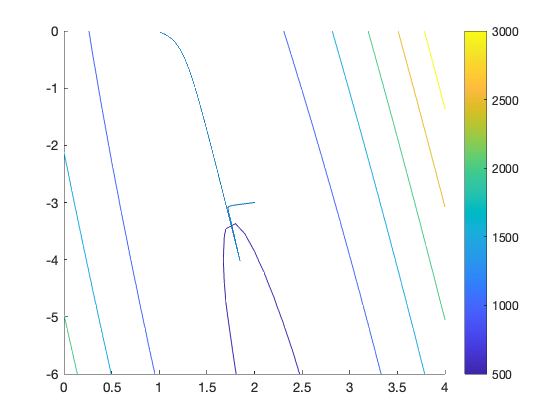

In [ ]:
K =5000;
learning_eps = 0.001;
c = (2+1)^2 + (3+1)^2; %set randomly as a constraint
fL2c = @(a,b,alpha)(f(a,b) + alpha*(a^2 + b^2 -c));
ffL2c = @(a,b,alpha)(grad_rss3e(a, b, alpha, c, X, Y));
alpha0 = 1;
[as, bs, alphas] = grad_desc_rss3e(K, a0, b0, alpha0, learning_eps, f, fL2c, ffL2c, true);

L2 constraint: a=1.00 b=-0.02 alpha=110.04 loss=627.46; a^2 + b^2 = 1.00; c=25.00


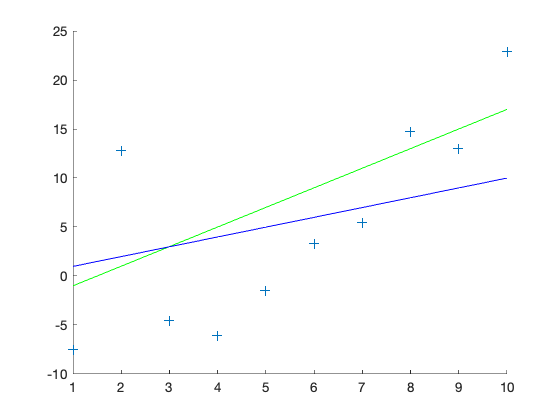

In [ ]:
fprintf("L2 constraint: a=%.2f b=%.2f alpha=%.2f loss=%.2f;",as(K+1),bs(K+1),alphas(K+1),rss2(as(K+1),bs(K+1),X,Y));
fprintf(" a^2 + b^2 = %.2f; c=%.2f",as(K+1)^2+bs(K+1)^2,c);
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,as(K+1)*X+bs(K+1),'color','b')
hold off

This does not seem to converge to a minumum: $a^2 + b^2 = 1 \neq c=25$. The problem is that when using Lagrange multipliers, the critical points don't occur at local minima of the Lagrangian - they occur at saddle points instead. Since the gradient descent algorithm is designed to find local minima, it fails to converge when we give it a problem with constraints.

Therefore, we optimize for the squared magnitude of the gradient, which is the sum of the squares of the partial derivatives. This is a transformation of the constraint problem such that the critical points occur at local minima. Details [here](https://en.wikipedia.org/wiki/Lagrange_multiplier#Example_4:_Numerical_optimization).

In our case the squared magnitude $M^2$ of the gradient $\nabla \mathcal{L}^2(a,b,\alpha)$ is:

$$
M^2(a,b,\alpha) = 
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)^2 +
\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)^2 +
\left ( \alpha (a^2 + b^2 -c) \right)^2 
$$

and its gradient is:

$$
\begin{align}
\nabla M^2(a,b,\alpha) &= 
\begin{bmatrix}
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n}-x_i^2+ 2 \alpha \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n}-x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right)\left (-2 \sum_{i=1}^{n} -x_i \right) 
+ 2\left (-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)\left (-2 \sum_{i=1}^{n} -1 + 2 \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\\
&= 
\begin{bmatrix}
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n}x_i^2+\alpha \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n}x_i \right) 
    + 4\alpha^2 a(a^2 + b^2 -c) \\
8\left (-\sum_{i=1}^{n}(y_i- a x_i-b)x_i + \alpha a \right)\left (\sum_{i=1}^{n} x_i \right) 
+ 8\left (-\sum_{i=1}^{n}(y_i- a x_i-b) + \alpha b \right)\left (\sum_{i=1}^{n} 1 + \alpha \right) 
+ 4\alpha^2 b(a^2 + b^2 -c) \\
-8a \left (\sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a \right) 
-8b \left (\sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b \right)
+2\alpha (a^2 + b^2 -c )^2
\end{bmatrix}
\end{align}$$

We don't want to further simplify this gradient nor use it to implement the optimization with gradient descent. Both is (error prone but) straight forward. 

See the "Constraint Optimization" notebook where we exercise this with a simpler optimization problem. 

### 4.2 Regularization with the $L^2$ Norm inequality constraint

A similar but not identical approach sets a **constraint** $c$ to the $L^2$ Norm of the parameters: $a^2 + b^2$. 

The regulated loss function is 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } a^2 + b^2& \leq c
\end{aligned}
$$  
for some a constant $c$.

The inequality constraint $(a^2 + b^2) \leq c$ is equal to the equality constraint $a^2 + b^2 - c + s^2 = 0$, where $s$ is a new free variable. For the loss function with the equality constraint, we define the generalized Lagrangian:

$$
\begin{aligned}
\mathcal{L}^2(a,b,\alpha,s) &= RSS(a,b) + \alpha(a^2 + b^2 -c +s^2)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(a^2 + b^2 -c +s^2)
\end{aligned}
$$

The gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^2(a,b,\alpha,s) 
&= \left [ \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial a}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial b}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial \alpha}, \frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial s}\right ]^T\\
&= \left [ 
\frac{\partial RSS(a,b)}{\partial a} + 2\alpha a, 
\frac{\partial RSS(a,b)}{\partial b} + 2\alpha b, 
a^2 + b^2 -c +s^2, 
2\alpha s\right ]^T\\
&= \left [
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i + 2 \alpha a, 
-2 \sum_{i=1}^{n}(y_i- a x_i-b) + 2 \alpha b, 
a^2 + b^2 -c +s^2, 
2\alpha s\right ]^T 
\end{aligned}
$$

In [ ]:
%%file grad_rss3.m
function grad_w = grad_rss3(a, b, alpha, s, c, X, Y)
    n = length(X);
    grad_a = 0;
    grad_b = 0;
    for i=1:n
        tmp = Y(i) - a*X(i) - b;
        grad_a = grad_a + tmp *X(i);
        grad_b = grad_b + tmp;
    end
    grad_a = -2*grad_a + 2*alpha*a;
    grad_b = -2*grad_b + 2*alpha*b;
    grad_alpha = a^2 + b^2 -c +s^2;
    grad_s = 2*alpha*s;
    grad_w = [grad_a; grad_b; grad_alpha; grad_s];
end

Created file '/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/grad_rss3.m'.


In [ ]:
%%file grad_desc_rss3.m
function [as, bs, alphas, ss] = grad_desc_rss3(K, a0, b0, alpha0, s0, learning_eps, f_orig, f, ff, verbose)
    as = zeros(K+1,1);
    bs = zeros(K+1,1);
    alphas = zeros(K+1,1);
    as = zeros(K+1,1);
    as(1)=a0;
    bs(1)=b0;
    alphas(1)=alpha0;
    ss(1)=s0;
    for k = 1:K
        grad_w = ff(as(k),bs(k),alphas(k),ss(k));
        grad_a = grad_w(1);
        grad_b = grad_w(2);
        grad_alpha = grad_w(3);
        grad_s = grad_w(4);
        as(k+1)= as(k) - learning_eps * grad_a;
        bs(k+1)= bs(k) - learning_eps * grad_b;
        alphas(k+1)= alphas(k) - learning_eps * grad_alpha;
        ss(k+1)= ss(k) - learning_eps * grad_s;
        if verbose
            line([as(k),as(k+1)],[bs(k),bs(k+1)])
            hold on
        end
    end
    grad_w = ff(as(k),bs(k),alphas(k),ss(k))
    ffinal = @(a,b)(f(a, b, alphas(K+1), ss(K+1)));
    if verbose
        alow = min([as.', a0-2]);
        ahigh = max([as.', a0+2]);
        blow = min([bs.', b0-3]);
        bhigh = max([bs.', b0+3]);
        [A,B] = meshgrid(alow:0.1:ahigh,blow:0.4:bhigh);
        plot3d(f_orig, A, B, false) %3D contour
        %plot3d(ffinal, A, B, false) %3D contour
    end
end

Created file '/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/grad_desc_rss3.m'.



grad_w =

    0.5872
   -3.6486
  -20.3558
    0.0388




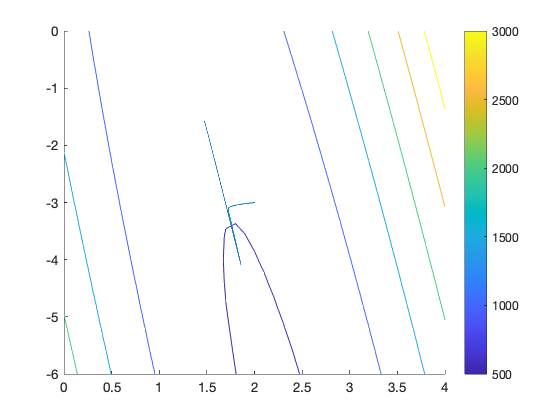

In [ ]:
K =1500;
learning_eps = 0.0005;
c = (2+1)^2 + (3+1)^2; %set randomly as a constraint
fL2c = @(a,b,alpha,s)(f(a,b) + alpha*(a^2 + b^2 -c +s^2));
ffL2c = @(a,b,alpha,s)(grad_rss3(a, b, alpha, s, c, X, Y));
alpha0 = 1;
s0 = 1;
[as, bs, alphas, ss] = grad_desc_rss3(K, a0, b0, alpha0, s0, learning_eps, f, fL2c, ffL2c, true);

L2 constraint: a=1.47 b=-1.57 alpha=9.31 s=0.00 loss=545.67; a^2 + b^2 = 4.64 < c=25.00


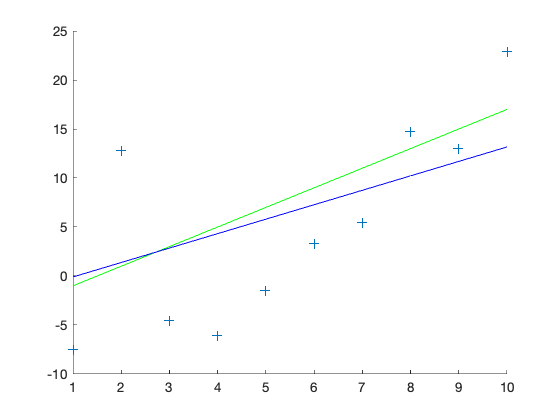

In [ ]:
fprintf("L2 constraint: a=%.2f b=%.2f alpha=%.2f s=%.2f loss=%.2f;",as(K+1),bs(K+1),alphas(K+1),ss(K+1),rss2(as(K+1),bs(K+1),X,Y));
fprintf(" a^2 + b^2 = %.2f < c=%.2f",as(K+1)^2+bs(K+1)^2,c);
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,as(K+1)*X+bs(K+1),'color','b')
hold off

Again, gradient descent does not seem to converge well since the critical points of Lagrangians occur at saddle points. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. We need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +2\alpha a&=0\\
\frac{\partial \mathcal{L}^2(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +2\alpha b&=0 \\
\alpha (a^2 + b^2 - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $a^2 + b^2 - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $a^2 + b^2 - c = 0$, i.e., the constraint is active, (3b) 

Case (3a) reduces to the unconstraint problem, which we have solved already. The solution was $a\approx 2.49$ and $b\approx -8.44$. Checking the constraint on this solutions let's us conclude it is not $<0$ and, hence, the solution is not  feasible:

In [ ]:
a_orig
b_orig
c = (2+1)^2 + (3+1)^2; %set randomly as a constraint (abs. values of a, b off by 1 from the act. unknown solution)
(a_orig)^2+(b_orig)^2-c 


a_orig =

    2.4898


b_orig =

   -8.4390


ans =

   52.4154




Case (3b) is equal to the equality constraint problem. It leads to the following system of equations that we can solve directly:

In [ ]:
eins= ones(N,1);
syms a b alpha;
eqn1 = -2 * ((Y-a*X-b)*X.') + 2* alpha*a==0; %(1)
eqn2 = -2 * ((Y-a*X-b)*eins) + 2* alpha*b==0; % (2)
eqn3 = a^2 + b^2 == c; %(3b)

In [ ]:
sol = vpasolve([eqn1, eqn2, eqn3], [a, b, alpha]);
a_hats= sol.a
b_hats=sol.b
alpha_hats = sol.alpha

 
a_hats =
 
 0.58379933471822097896904654975152
  4.9398929841976308084884395682197
 -4.9543687543664827576434499615103
  1.9345013494864786791236558040115
 
 
b_hats =
 
   4.9658008756677469683743971959886
  0.77295362388375258552306630096765
 -0.67396605682861064777583432080451
  -4.6106078263971869587240708892635
 
 
alpha_hats =
 
 -5.8833344684503757749388851907125
 -293.51326994092063434437857852273
 -492.28213113663835828711356022008
  1.6787355460093684064310239335203
 



There are several local optima fulfilling the constraint. Some are maybe local minima, some local maxima. We would need to check the second order condition involving the Hessian (deliberately omitted here). We just pick the solution with the minimum unregulated loss function (original $RSS$) value, which is $a\approx 1.93$ and $b\approx -4.61$ leading to $RSS\approx475.53$.

L2 constraint: a=0.58 b=4.97 alpha=-5.88 loss=829.18 feasible: a^2 + b^2 = 25.00 == c=25.00
L2 constraint: a=4.94 b=0.77 alpha=-293.51 loss=6086.41 feasible: a^2 + b^2 = 25.00 == c=25.00
L2 constraint: a=-4.95 b=-0.67 alpha=-492.28 loss=16023.86 feasible: a^2 + b^2 = 25.00 == c=25.00
L2 constraint: a=1.93 b=-4.61 alpha=1.68 loss=475.53 feasible: a^2 + b^2 = 25.00 == c=25.00



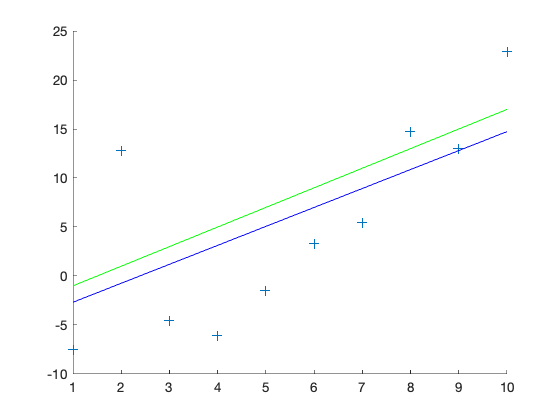

In [ ]:
min_rss = realmax;
arg_min = 0;
for i =1:length(a_hats)
    a_hat = a_hats(i);
    b_hat = b_hats(i);
    alpha_hat = alpha_hats(i);
    rss = rss2(a_hat,b_hat,X,Y);
    if min_rss > rss
        arg_min = i;
        min_rss = rss;
    end
    fprintf("L2 constraint: a=%.2f b=%.2f alpha=%.2f loss=%.2f",a_hat,b_hat,alpha_hat,rss);
    fprintf(" feasible: a^2 + b^2 = %.2f == c=%.2f\n",(a_hat)^2+(b_hat)^2,c);
end
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,a_hats(arg_min)*X+b_hats(arg_min),'color','b')
hold off

## Regularization with the $L^1$ Norm constraint

Finally we can set a constraint to the $L^1$ Norm of the parameters: $|a| + |b|$. 

The regulated loss function is 
$$
\begin{aligned}
(\hat a, \hat b) = \arg \min_{a,b} RSS(a,b)&=\sum_{i=1}^{n}(y_i- a x_i - b)^2\\
\text{subject to } |a| + |b|& \leq c
\end{aligned}
$$  
for some parameter $\alpha$ and a constant $c$.

The inequality constraint $|a| + |b| \leq c$ is equal to the equality constraint $|a| + |b| - c + s^2 = 0$. For the loss function with the equality constraint, we define the generalized Lagrangian:

$$
\begin{aligned}
\mathcal{L}^1(a,b,\alpha,s) &= RSS(a,b) + \alpha(|a| + |b| -c +s^2)\\
&= \sum_{i=1}^{n}(y_i- a x_i - b)^2 + \alpha(|a| + |b| -c +s^2)
\end{aligned}
$$

The the gradient of is (now unconstraint) problem is:

$$
\begin{aligned}
\nabla \mathcal{L}^1(a,b,\alpha,s) 
&= \left [ \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial a}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial b}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial \alpha}, \frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial s}\right ]^T\\
&= \left [ \frac{\partial RSS(a,b)}{\partial a} +\alpha\ \text{sign}(a), \frac{\partial RSS(a,b)}{\partial b}+\alpha\ \text{sign}(b), |a| + |b| -c +s^2, 2\alpha s\right ]^T\\
&= \left [-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a), -2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\ \text{sign}(b), |a| + |b| -c +s^2, 2\alpha s\right ]^T 
\end{aligned}
$$

In [ ]:
%%file grad_rss4.m
function grad_w = grad_rss4(a, b, alpha, s, c, X, Y)
    n = length(X);
    grad_a = 0;
    grad_b = 0;
    for i=1:n
        tmp = Y(i) - a*X(i) - b;
        grad_a = grad_a + tmp *X(i);
        grad_b = grad_b + tmp;
    end
    grad_a = -2*grad_a + alpha*sign(a);
    grad_b = -2*grad_b + alpha*sign(b);
    grad_alpha = abs(a) + abs(b) -c +s^2;
    grad_s = 2*alpha*s;
    grad_w = [grad_a; grad_b; grad_alpha; grad_s];
end

Created file '/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/grad_rss4.m'.



grad_w =

   -1.1082
    7.7007
    1.9451
    1.0344




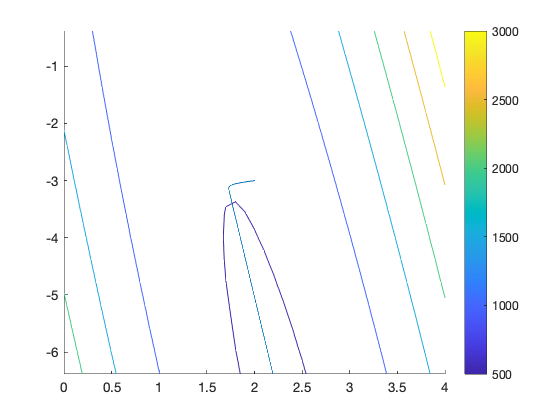

In [ ]:
K = 500;
learning_eps = 0.0005;
c = (2+1) + (3+1);
fL1c = @(a,b,alpha,s)(f(a,b) + alpha*(abs(a) + abs(b) -c +s^2));
ffL1c = @(a,b,alpha,s)(grad_rss4(a, b, alpha, s, c, X, Y));
[as, bs, alphas, ss] = grad_desc_rss3(K, a0, b0, alpha0, s0, learning_eps, f, fL1c, ffL1c, true);

L1 constraint: a=2.19 b=-6.38 alpha=0.85 s=0.61 loss=453.16 |a| + |b| = 8.58 < c=7.00


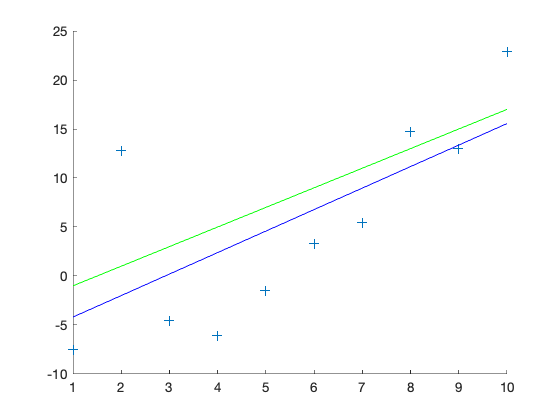

In [ ]:
fprintf("L1 constraint: a=%.2f b=%.2f alpha=%.2f s=%.2f loss=%.2f",as(K+1),bs(K+1),alphas(K+1),ss(K+1),rss2(as(K+1),bs(K+1),X,Y));
fprintf(" |a| + |b| = %.2f < c=%.2f",abs(as(K+1))+abs(bs(K+1)),c);
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,as(K+1)*X+bs(K+1),'color','b')
hold off

Gradient descent does not seem to converge well. Even the constraint is violated. Therefore, we solve the constraint optimization problem with the Karush–Kuhn–Tucker (KKT) approach. Again, we need to check the KKT conditions:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial a} &=0 \ \ \ \ \ (1)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b)x_i +\alpha\ \text{sign}(a) &=0\\
\frac{\partial \mathcal{L}^1(a,b,\alpha,s)}{\partial b} &=0 \ \ \ \ \ (2)\\
-2 \sum_{i=1}^{n}(y_i- a x_i-b) +\alpha\ \text{sign}(b) &=0 \\
\alpha (|a| + |b| - c) &=0 \ \ \ \ \ (3)
\end{aligned}
$$

We need to distinguish two cases for (3): 
- $\alpha = 0$ and $|a| + |b| - c < 0$, i.e., the constraint is inactive, (3a) 
- $\alpha > 0$ and $|a| + |b| - c = 0$, i.e., the constraint is active, (3b) 

Case (3a) reduces to the unconstraint problem, which we have solved: $a\approx 2.49$ and $b\approx -8.44$. Checking the constraint on this solutions let's us conclude it is not $<0$ and, hence, the solution is not  feasible:

In [ ]:
c = (2+1) + (3+1);
abs(a_orig)+abs(b_orig)-c 


ans =

    3.9288




Case (3b) leads to the following system of equations:

In [ ]:
eins= ones(N,1);
syms a b alpha;
eqn1 = -2 * ((Y-a*X-b)*X.') + alpha*sign(a)==0;
eqn2 = -2 * ((Y-a*X-b)*eins) + alpha*sign(b)==0;
eqn3 = abs(a) + abs(b) == c;

In [ ]:
sol = vpasolve([eqn1, eqn2, eqn3], [a, b, alpha]);
a_hat= sol.a;
b_hat=sol.b;
alpha_hat = sol.alpha;

L1 constraint: a=0.45 b=6.55 alpha=-74.97 loss=929.50 |a| + |b| = 7.00 == c=7.00


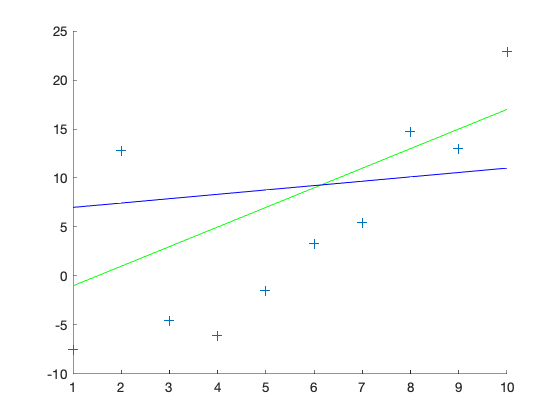

In [ ]:
fprintf("L1 constraint: a=%.2f b=%.2f alpha=%.2f loss=%.2f",a_hat,b_hat,alpha_hat,rss2(a_hat,b_hat,X,Y));
fprintf(" |a| + |b| = %.2f == c=%.2f",abs(a_hat)+abs(b_hat),c);
scatter(X,Y,'+')
hold on
plot(X,a0*X+b0,'color','g')
plot(X,a_hat*X+b_hat,'color','b')
hold off

## Regularization of underconstraint problems

Let's look at a problem with two predictors and generate some test data. We set $a_1=a_2=2$ and $b=-3$ and generate $100$ datapoints $Y=a_1X_1+a_2X_2 + b$ where $X_1, X_2\in [1,10]$ with a random error that is normally distributed proportional to $\mathcal{N}(0,10)$. 

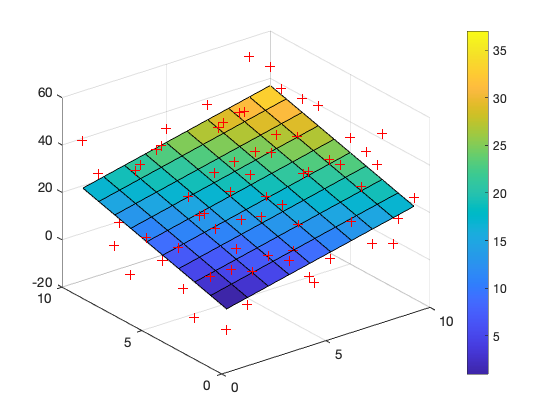

In [ ]:
XX=fliplr(fullfact([N N]));
a10 = 2;
a20 = 2;
b0 = -3;
X1 = XX(:,1);
X2 = XX(:,2);

f0 = @(x1,x2)(a10*x1 + a20*x2 + b0);
f = @(x1,x2,r)(a10*x1 + a20*x2 + b0 + r);
R = normrnd(0,10,1,N*N).';
Y = arrayfun(f,X1,X2,R);
[A,B] = meshgrid(1:N,1:N);
plot3d(f0,A,B, true);
hold on
scatter3(X1,X2,Y,'r+')

Let's check the error $RSS_0$ for the initial parameters, learn new parameters from the generated data with linear regression minimizing $RSS$, and then check again this new error.

* $\verb|XS = [ones(N*N,1), XX]|$ Adds a bias term (column of 1's) to the design matrix XX. This makes XS a matrix of size (N*N*3), where the first column handles the intercept b0, and the rest are our features a10 and a20.

* $\verb|w0 = [b0, a10, a20].'|$ is the weight vector for checking an initial guess.

* $\verb|RSS0 = (Y - XS * w0).' * (Y - XS * w0)|$ computes the Residual Sum of Squares (RSS) for w0.

* $\verb|w = inv(XS.' * XS) * XS.' * Y|$ is the closed-form solution for linear regression: $w=(X^T X)^{−1} X^T Y$ minimizes the Mean Squared Error (or equivalently, the RSS), giving the best-fitting line/hyperplane in the least-squares sense.

In [ ]:
XS = [ones(N*N,1), XX];
w0 = [b0, a10, a20].';
RSS0 = (Y - XS* w0).' * (Y - XS* w0)
w = inv(XS.'*XS)*XS.'*Y
RSS = (Y - XS* w).' * (Y - XS* w)


RSS0 =

   1.0344e+04


w =

   -4.8482
    2.1845
    2.1556


RSS =

   1.0296e+04




We make it an underspecified problem by just keeping data points with $X_1=1$, i.e., we don't see any variability in this dimension. This makes $X^TX$ a singular matrix and, hence, not invertible. Analytically, we cannot find a solution any longer.

In [ ]:
uXX = XX(1:N,:);
uY = Y(1:N);
uXS = [ones(N,1), uXX];
RSS0 = (uY - uXS* w0).' * (uY - uXS* w0)
w = inv(uXS.' * uXS) * uXS.' * uY;


RSS0 =

   1.5473e+03





With the suggested regularization, $X^TX \rightarrow X^TX +\alpha I$ gets invertible and we find an approximate solution analytically.

In [ ]:
alpha = 0.1;
I = eye(3);
w = inv(uXS.' * uXS + alpha *I) * uXS.' * uY
RSS = (uY - uXS* w).' * (uY - uXS* w)


w =

   -4.3887
   -4.3887
    3.2780


RSS =

   1.3993e+03


